In [11]:
from glob import glob
import os
import pandas as pd

In [2]:
!pwd

/Users/hanif/Bootcamp/Winter_1403


In [12]:
path_list = glob("./mnist-pngs/**/*.png", recursive=True)

In [14]:
path_frame = pd.DataFrame({
    "path" : path_list
})

In [23]:
path_frame["type"] = path_frame["path"].apply(lambda x: x.split("/")[-3])
path_frame["label"] = path_frame["path"].apply(lambda x: x.split("/")[-2])

In [24]:
path_frame

,path,type,label
0,./mnist-pngs/test/9/66710.png,test,9
1,./mnist-pngs/test/9/69423.png,test,9
2,./mnist-pngs/test/9/65219.png,test,9
3,./mnist-pngs/test/9/67426.png,test,9
4,./mnist-pngs/test/9/69386.png,test,9
...,...,...,...
69995,./mnist-pngs/train/5/31651.png,train,5
69996,./mnist-pngs/train/5/437.png,train,5
69997,./mnist-pngs/train/5/33734.png,train,5
69998,./mnist-pngs/train/5/40902.png,train,5


In [33]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [31]:
img = Image.open(path_frame["path"].iloc[0])

In [34]:
img = np.array(img)

In [37]:
img.shape

(28, 28)

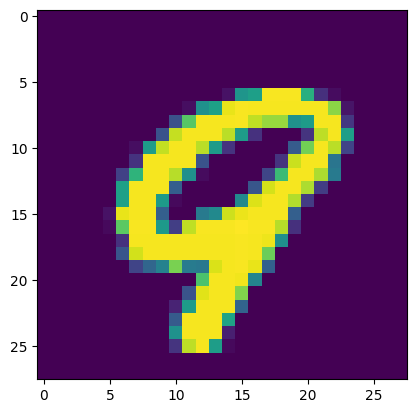

In [36]:
plt.imshow(img)

In [43]:
train_frame = path_frame[path_frame["type"]=="train"]
display(train_frame)
train_data = [np.array(Image.open(item)) for item in train_frame["path"]]

,path,type,label
10000,./mnist-pngs/train/9/36655.png,train,9
10001,./mnist-pngs/train/9/32433.png,train,9
10002,./mnist-pngs/train/9/28319.png,train,9
10003,./mnist-pngs/train/9/4968.png,train,9
10004,./mnist-pngs/train/9/23502.png,train,9
...,...,...,...
69995,./mnist-pngs/train/5/31651.png,train,5
69996,./mnist-pngs/train/5/437.png,train,5
69997,./mnist-pngs/train/5/33734.png,train,5
69998,./mnist-pngs/train/5/40902.png,train,5


In [46]:
xTrain = np.array(train_data)

In [48]:
xTrain.shape

(60000, 28, 28)

In [57]:
test_frame = path_frame[path_frame["type"]=="test"]
display(test_frame)
test_data = [np.array(Image.open(item)) for item in test_frame["path"]]
xTest = np.array(test_data)

In [58]:
xTest.shape

(10000, 28, 28)

In [54]:
yTrain = train_frame["label"].values.astype(int)
yTest = test_frame["label"].values.astype(int)

In [ ]:
# normalization

In [64]:
xTrain = xTrain / 255
xTest = xTest / 255

In [60]:
import tensorflow as tf
from tensorflow.keras import layers

In [86]:
input_layer = tf.keras.Input(shape=(xTrain.shape[1:]))

model = layers.Flatten()(input_layer)

model = layers.Dense(128, activation="elu")(model)
model = layers.Dropout(0.2)(model)

model = layers.Dense(64, activation='elu')(model)
model = layers.Dropout(0.2)(model)

model = layers.Dense(len(np.unique(yTrain)), activation="softmax")(model)

model = tf.keras.Model(input_layer, model)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
model.compile(optimizer="adam", loss="categorical_crossentropy")

In [88]:
model.fit(xTrain, tf.keras.utils.to_categorical(yTrain), epochs=50, batch_size=512, validation_split=0.3)

Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.8854 - val_loss: 6.7181
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2074 - val_loss: 7.3319
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1661 - val_loss: 7.9926
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1590 - val_loss: 8.1396
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1311 - val_loss: 8.5338
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1227 - val_loss: 8.8298
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1073 - val_loss: 8.9546
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1073 - val_loss: 8.9846
Epoch 9/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0981 - val_loss: 9.6209
Epoch 10/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0875 - val_loss: 9.5772
Epoch 11/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0848 - val_loss: 9.3257
Epoch 12/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0826 - val_lo

In [91]:
y_pred = np.argmax(model.predict(xTest), 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step


In [92]:
from sklearn.metrics import classification_report

In [93]:
print(classification_report(yTest, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.99      0.89       980
           1       0.84      0.99      0.91      1135
           2       0.00      0.00      0.00      1032
           3       0.00      0.00      0.00      1010
           4       0.92      0.98      0.95       982
           5       0.00      0.00      0.00       892
           6       0.76      0.99      0.86       958
           7       0.80      0.98      0.88      1028
           8       0.38      0.98      0.55       974
           9       0.69      0.97      0.81      1009

    accuracy                           0.70     10000
   macro avg       0.52      0.69      0.59     10000
weighted avg       0.53      0.70      0.59     10000



/Users/hanif/miniconda3/envs/mlseq/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/hanif/miniconda3/envs/mlseq/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/hanif/miniconda3/envs/mlseq/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz